In [1]:
from plot_mimiciv_segment_lens import list_h5_files

In [2]:
import boto3, s3fs
import h5py
import hdf5plugin  
import matplotlib.pyplot as plt
import numpy as np

In [3]:
bucket = "walkky-datasets"
prefix = "extracted-ecg-waveforms/mimic-iv/"

SEGMENTS = ("P", "PQ", "QRS", "ST", "T", "TP")
NLEADS = 12

In [4]:
file_list = list_h5_files(bucket, prefix)
print(f"Number of h5 files = {len(file_list)}, Examples: {file_list[:5]}")

Number of h5 files = 44, Examples: ['extracted-ecg-waveforms/mimic-iv/extracted_waveforms__worker_0.h5', 'extracted-ecg-waveforms/mimic-iv/extracted_waveforms__worker_1.h5', 'extracted-ecg-waveforms/mimic-iv/extracted_waveforms__worker_10.h5', 'extracted-ecg-waveforms/mimic-iv/extracted_waveforms__worker_11.h5', 'extracted-ecg-waveforms/mimic-iv/extracted_waveforms__worker_12.h5']


In [47]:
file_idx = 0 # Select a random file
record_idx = 2 # Select a random beat cycle index for a random patient and study

beat_start_idx = record_idx*NLEADS
beat_end_idx = (record_idx+1)*NLEADS

data : dict[str, np.ndarray] = {}

fs = s3fs.S3FileSystem()
filename = file_list[file_idx]
with fs.open(f"s3://{bucket}/{filename}", 'rb') as f:
    with h5py.File(f, 'r') as h5file:
        for seg in SEGMENTS:
            if seg not in h5file:
                continue
            n = int(h5file[seg]["data"].shape[0])
            if n == 0:
                continue
            patient_id = np.unique(np.array(h5file[seg]['patient_id'][beat_start_idx:beat_end_idx]))
            study_id = np.unique(np.array(h5file[seg]['study_id'][beat_start_idx:beat_end_idx]))
            beat_idx = np.unique(np.array(h5file[seg]['beat_idx'][beat_start_idx:beat_end_idx]))
            leads_idx = np.array(h5file[seg]['lead_idx'][beat_start_idx:beat_end_idx])
            print(f"Patient id {patient_id}, study id {study_id}, beat idx {beat_idx}, leads {leads_idx}")
            data[seg] = np.array(h5file[seg]["data"][beat_start_idx:beat_end_idx], dtype=np.float32)
            print(f"File: {filename}, segment: {seg}, length: {data[seg].shape}")


Patient id [b'13976674'], study id [b'49959214'], beat idx [3], leads [ 0  1  2  3  4  5  6  7  8  9 10 11]
File: extracted-ecg-waveforms/mimic-iv/extracted_waveforms__worker_0.h5, segment: P, length: (12, 800)
Patient id [b'13976674'], study id [b'49959214'], beat idx [3], leads [ 0  1  2  3  4  5  6  7  8  9 10 11]
File: extracted-ecg-waveforms/mimic-iv/extracted_waveforms__worker_0.h5, segment: PQ, length: (12, 800)
Patient id [b'13976674'], study id [b'49959214'], beat idx [3], leads [ 0  1  2  3  4  5  6  7  8  9 10 11]
File: extracted-ecg-waveforms/mimic-iv/extracted_waveforms__worker_0.h5, segment: QRS, length: (12, 800)
Patient id [b'13976674'], study id [b'49959214'], beat idx [3], leads [ 0  1  2  3  4  5  6  7  8  9 10 11]
File: extracted-ecg-waveforms/mimic-iv/extracted_waveforms__worker_0.h5, segment: ST, length: (12, 800)
Patient id [b'13976674'], study id [b'49959214'], beat idx [3], leads [ 0  1  2  3  4  5  6  7  8  9 10 11]
File: extracted-ecg-waveforms/mimic-iv/extra

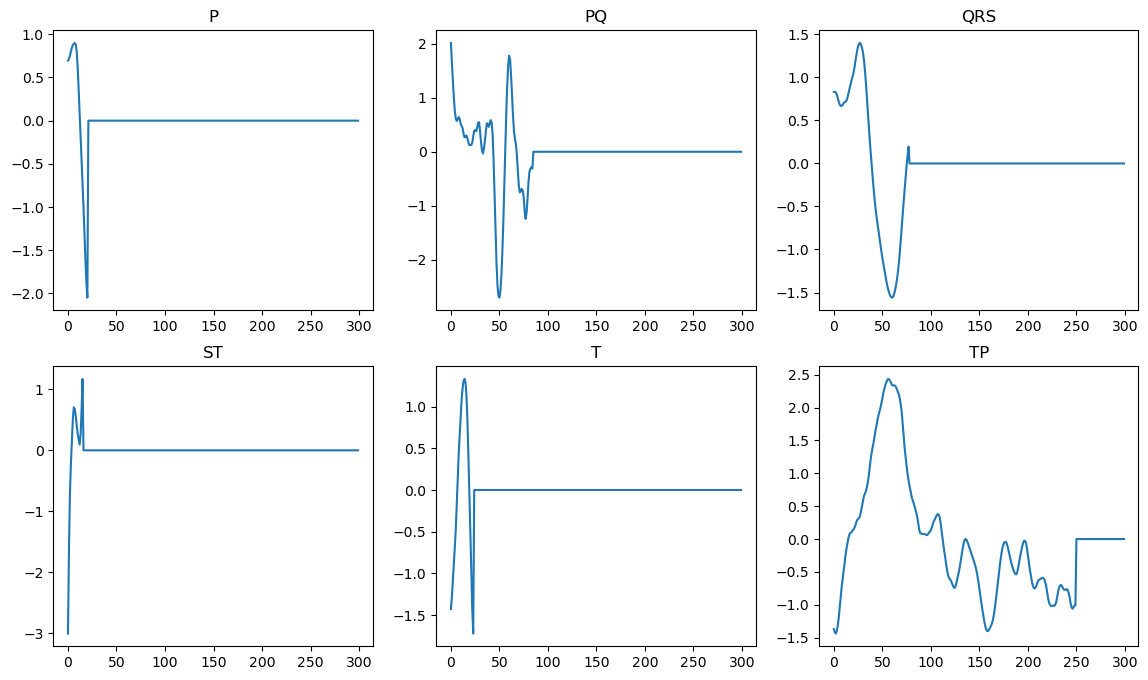

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()
lead_idx = 1 # Lead II
TRUNC_LEN = 300 # Truncate the signal already truncated and zero-padded to 800

for i, seg in enumerate(SEGMENTS):
    ax = axes_flat[i]
    ax.plot(data[seg][lead_idx, :TRUNC_LEN])
    ax.set_title(seg)
    